In [29]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC as SupportVectorMachineClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance
from xgboost import XGBClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import ParameterGrid
from imblearn.under_sampling import NearMiss
from scipy.stats import wilcoxon

In [2]:
df = pd.read_csv('heart_failure.csv')

In [3]:
df

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,1,270,0
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0,271,0
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0,278,0
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,1,280,0


In [4]:
df.columns

Index(['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes',
       'ejection_fraction', 'high_blood_pressure', 'platelets',
       'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time',
       'DEATH_EVENT'],
      dtype='str')

In [5]:
numerical_features = ["age", "creatinine_phosphokinase", "ejection_fraction", "platelets", "serum_creatinine", "serum_sodium"]
print("Numerical features:")
print(numerical_features)

Numerical features:
['age', 'creatinine_phosphokinase', 'ejection_fraction', 'platelets', 'serum_creatinine', 'serum_sodium']


In [6]:
categorical_features = ["anaemia", "diabetes", "high_blood_pressure", "sex", "smoking"]
print("Categorical features:")
print(categorical_features)

Categorical features:
['anaemia', 'diabetes', 'high_blood_pressure', 'sex', 'smoking']


In [7]:
df.info(categorical_features)

<class 'pandas.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [8]:
df.info(numerical_features)

<class 'pandas.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 30.5 KB


In [9]:
all_features = categorical_features.copy()
all_features.extend(numerical_features)

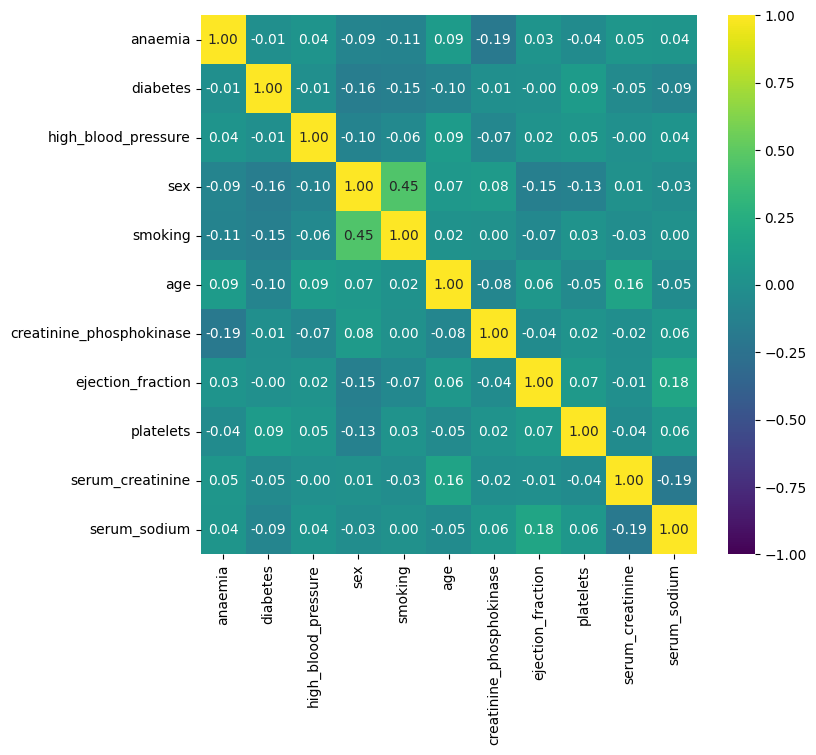

In [10]:
# Correlation Matrix
plt.figure(figsize=(8, 7))
sns.heatmap(df[all_features].corr(method='pearson'), vmin=-1, vmax=1, cmap='viridis', annot=True, fmt='.2f');

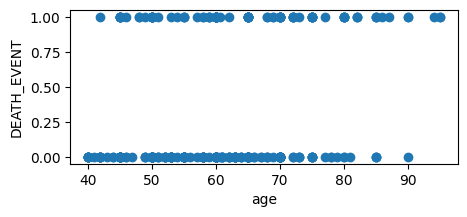

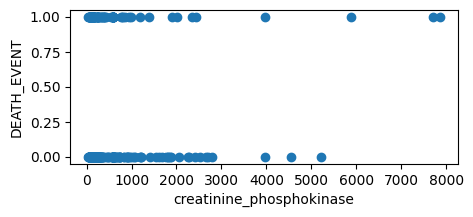

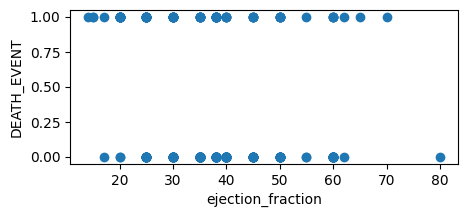

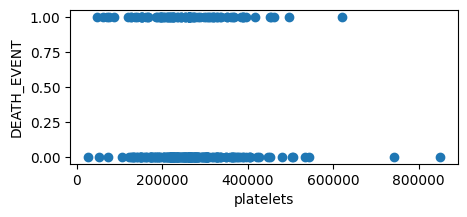

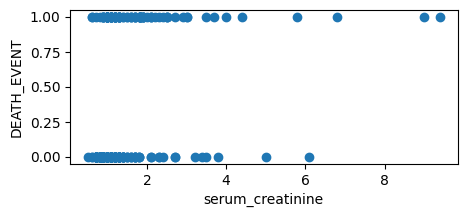

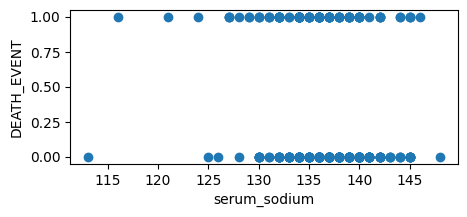

In [11]:
# Scatter Plot
for feature in numerical_features:
  plt.figure(figsize=(5, 2))
  plt.scatter(df[feature], df['DEATH_EVENT'])
  plt.xlabel(feature)
  plt.ylabel('DEATH_EVENT')
  plt.show()


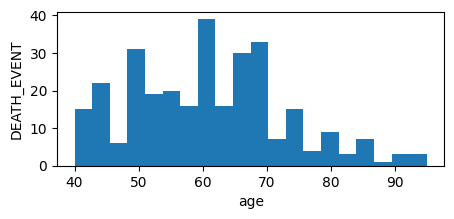

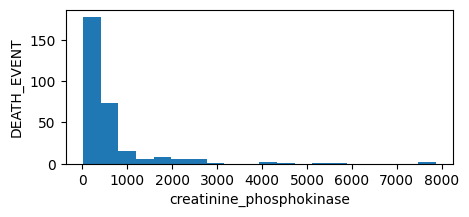

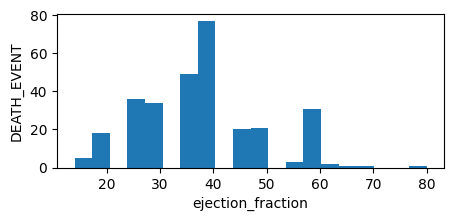

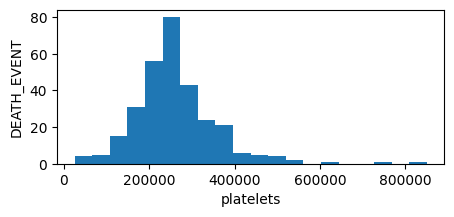

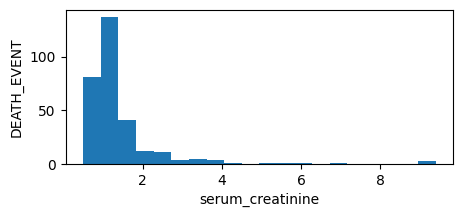

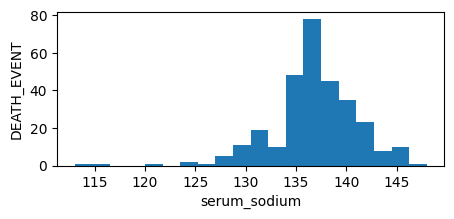

In [12]:
# Histogram
for feature in numerical_features:
  plt.figure(figsize=(5, 2))
  plt.hist(df[feature], bins=20)
  plt.xlabel(feature)
  plt.ylabel('DEATH_EVENT')
  plt.show()

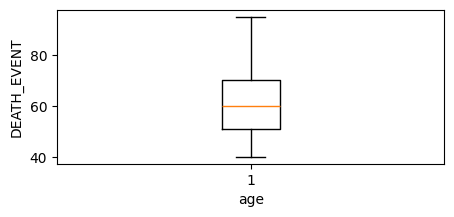

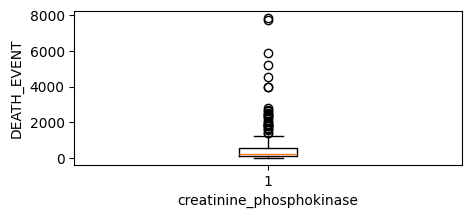

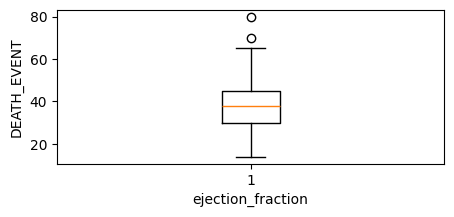

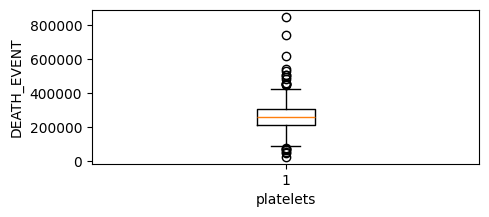

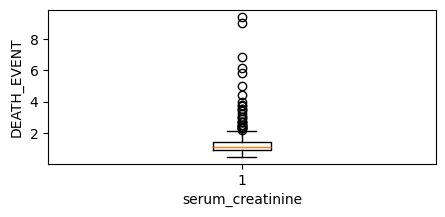

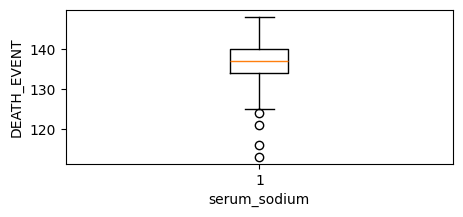

In [13]:
for feature in numerical_features:
  plt.figure(figsize=(5, 2))
  plt.boxplot(df[feature])
  plt.xlabel(feature)
  plt.ylabel('DEATH_EVENT')
  plt.show()

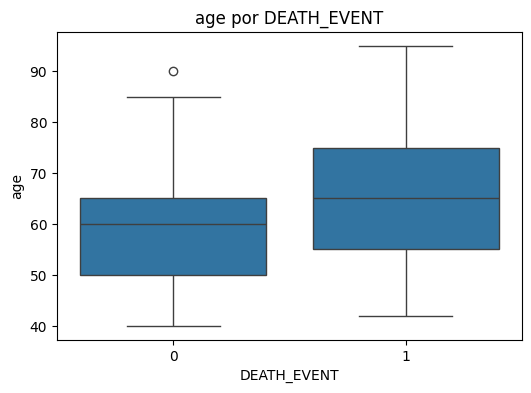

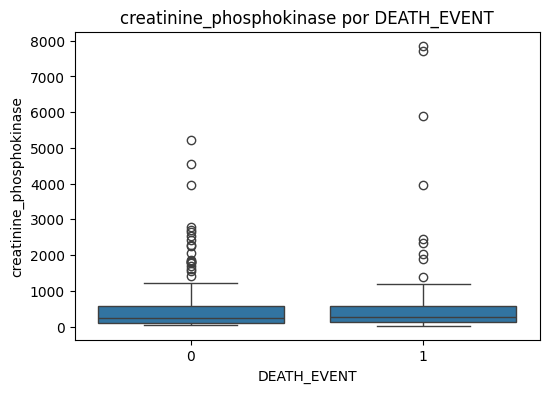

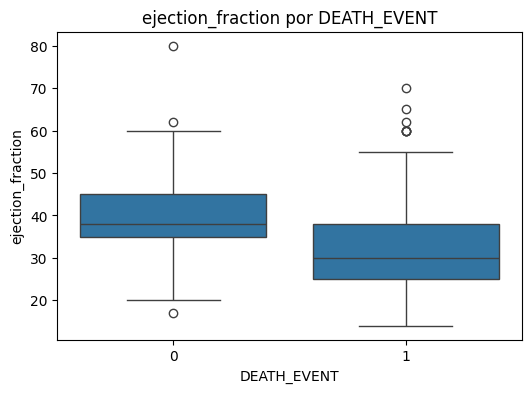

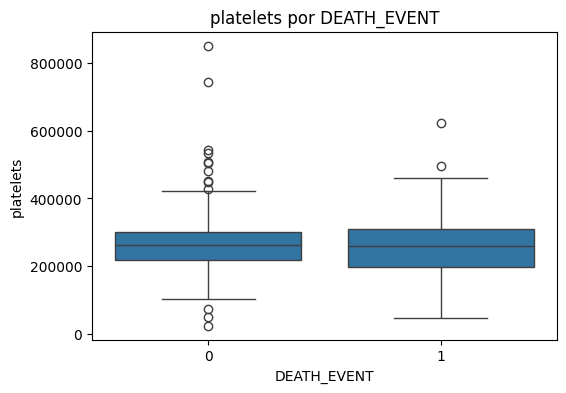

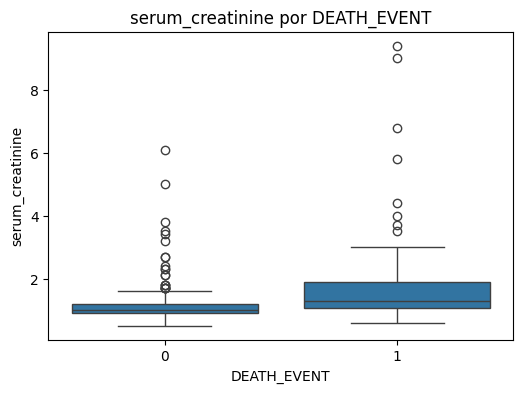

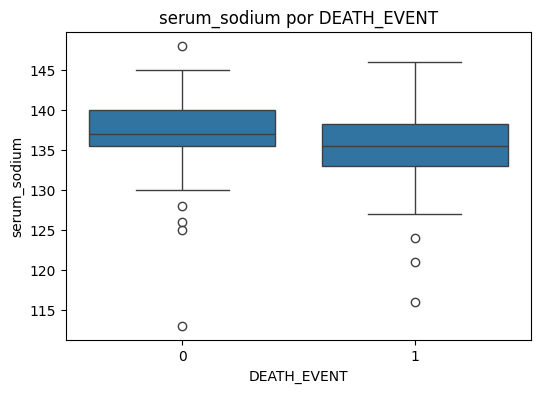

In [14]:
for feature in numerical_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='DEATH_EVENT', y=feature, data=df)
    plt.title(f'{feature} por DEATH_EVENT')
    plt.show()

In [15]:
df = df.drop(columns=['time', 'sex'])

In [16]:
df

,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,smoking,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,0,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,0,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,0,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,1
...,...,...,...,...,...,...,...,...,...,...,...
294,62.0,0,61,1,38,1,155000.00,1.1,143,1,0
295,55.0,0,1820,0,38,0,270000.00,1.2,139,0,0
296,45.0,0,2060,1,60,0,742000.00,0.8,138,0,0
297,45.0,0,2413,0,38,0,140000.00,1.4,140,1,0


In [17]:
X = df.drop('DEATH_EVENT', axis=1)
y = df['DEATH_EVENT']

nm = NearMiss()
X_undersampled, y_undersampled = nm.fit_resample(X, y)

In [18]:
df_cleaned = pd.Series(y_undersampled).value_counts()
print("Class distribution after NearMiss:")
print(df_cleaned)

Class distribution after NearMiss:
DEATH_EVENT
0    96
1    96
Name: count, dtype: int64


<Axes: title={'center': 'Class Distribution After NearMiss'}, xlabel='DEATH_EVENT'>

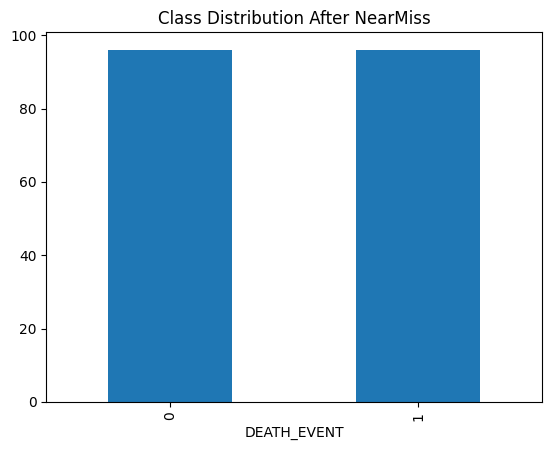

In [22]:
df_cleaned.plot(kind='bar', title='Class Distribution After NearMiss')


In [19]:
X = X_undersampled.values
y = y_undersampled.values

In [25]:
print("Shape of X_undersampled:", X_undersampled.shape)
print("Shape of y_undersampled:", y_undersampled.shape)

Shape of X_undersampled: (192, 10)
Shape of y_undersampled: (192,)


In [26]:
df_cleaned.value_counts('DEATH_EVENT')

count
96    1.0
Name: proportion, dtype: float64

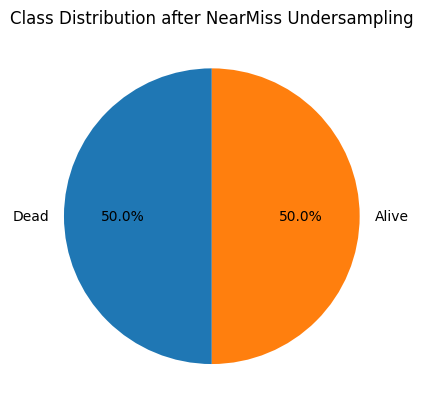

In [27]:
# SETORIAL GRAPHIC FOR CLASS
labels = ['Dead', 'Alive']
sizes = [df_cleaned[0], df_cleaned[1]] # Accessing counts by index directly
fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Class Distribution after NearMiss Undersampling')
plt.show()

In [30]:
pca = PCA(n_components=2)
componentes_principais = pca.fit_transform(X_undersampled)
# Crio um DataFrame temporário só pra ser mais fácil de pintar
df_pca = pd.DataFrame(data=componentes_principais, columns=['PC1', 'PC2'])
# Adiciono uma coluna com a resposta certa (Y) para ele colorir os pontinhos
# Assumindo que a sua resposta é o 'y'
df_pca['Classe_Alvo'] = y


<Axes: xlabel='PC1', ylabel='PC2'>

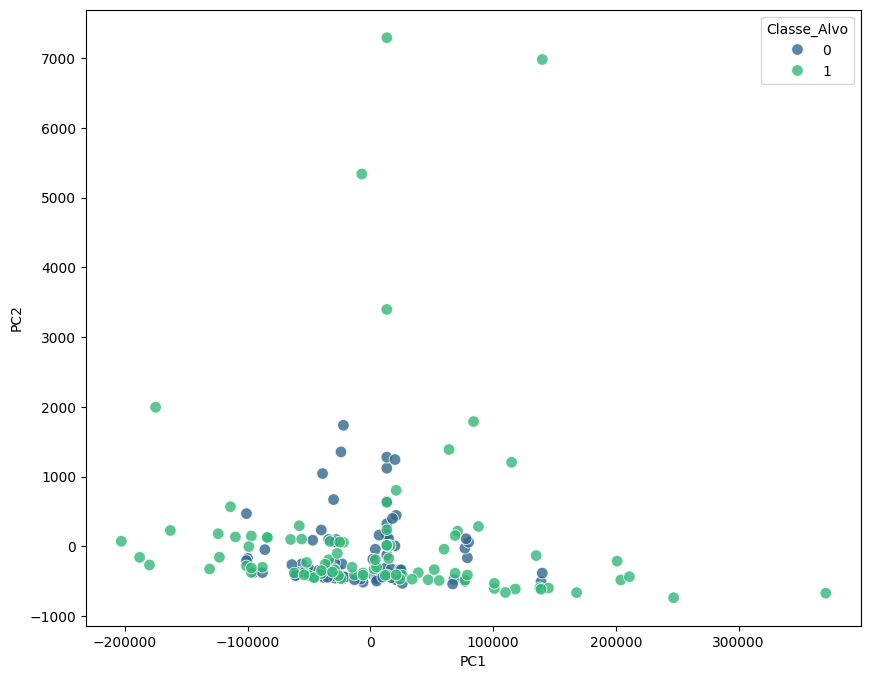

In [31]:

plt.figure(figsize=(10, 8))
# O seaborn desenha o Scatter Plot com Cores automáticas!
sns.scatterplot(
    x='PC1', 
    y='PC2', 
    hue='Classe_Alvo', 
    palette='viridis', # Tente 'Set1' ou 'coolwarm' também
    data=df_pca, 
    alpha=0.8,
    s=70 # Tamanho da bolinha
)



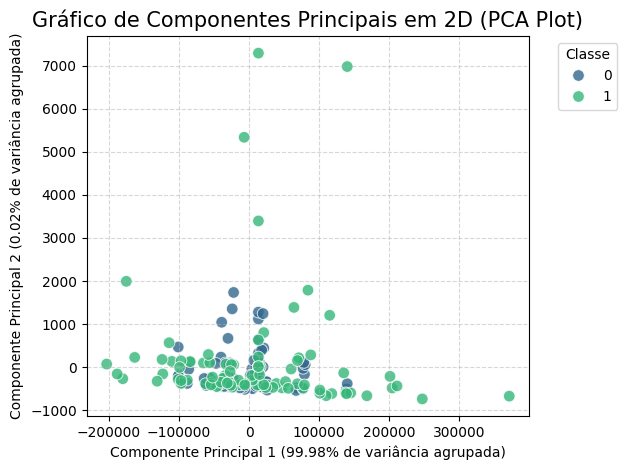

In [32]:
sns.scatterplot(x='PC1', y='PC2', hue='Classe_Alvo', palette='viridis', data=df_pca, alpha=0.8, s=70)
expl_1 = pca.explained_variance_ratio_[0]*100
expl_2 = pca.explained_variance_ratio_[1]*100
plt.title('Gráfico de Componentes Principais em 2D (PCA Plot)', fontsize=15)
plt.xlabel(f"Componente Principal 1 ({expl_1:.2f}% de variância agrupada)")
plt.ylabel(f"Componente Principal 2 ({expl_2:.2f}% de variância agrupada)")
plt.legend(title='Classe', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

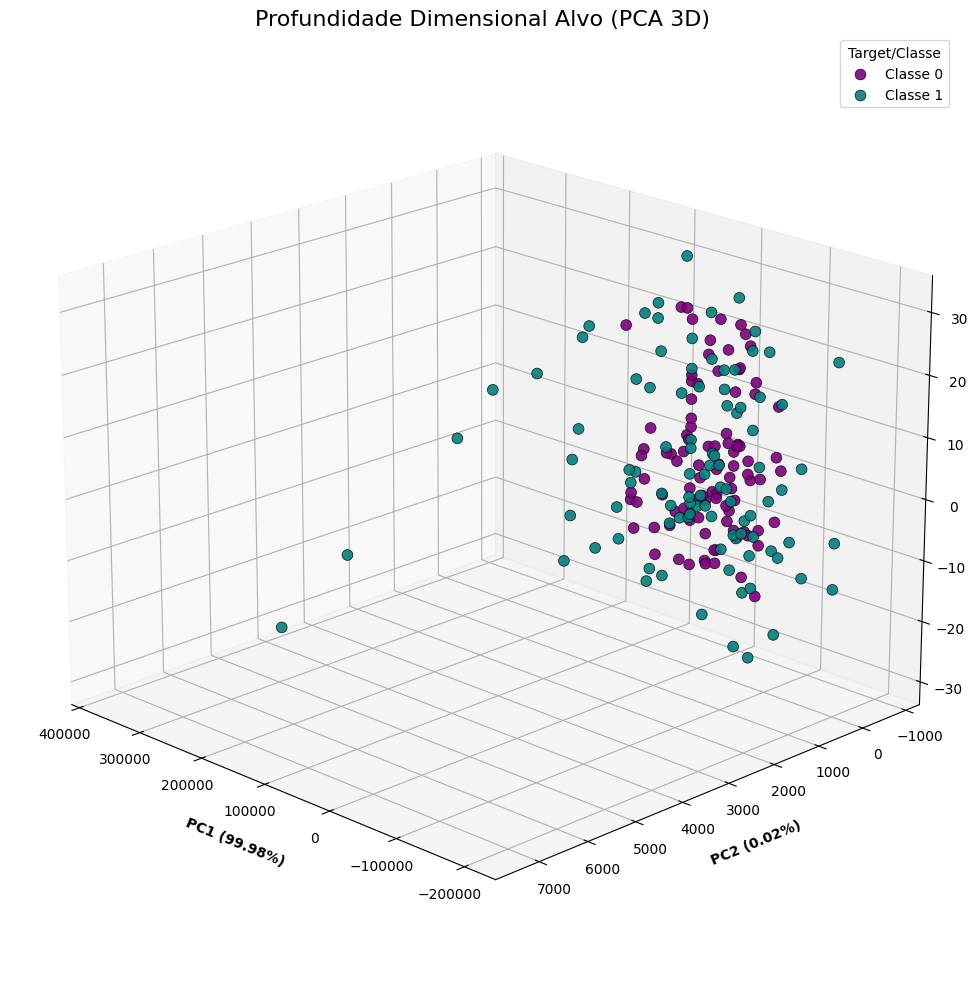

In [33]:
pca_3d = PCA(n_components=3)
comps_3d = pca_3d.fit_transform(X_undersampled)
    
df_pca3 = pd.DataFrame(data=comps_3d, columns=['PC1', 'PC2', 'PC3'])
df_pca3['Classe_Alvo'] = y
    
# Matplotlib puro pro 3D 
fig3d = plt.figure(figsize=(12, 10))
ax = fig3d.add_subplot(111, projection='3d')

cores = ['purple', 'teal', 'gold'] 
classes_unicas = sorted(list(df_pca3['Classe_Alvo'].unique()))
    
# Plota classe por classe
for cls, cor in zip(classes_unicas, cores):
    subset = df_pca3[df_pca3['Classe_Alvo'] == cls]
    ax.scatter(subset['PC1'], subset['PC2'], subset['PC3'], 
                color=cor, label=f'Classe {cls}', s=60, alpha=0.9, edgecolor='black', linewidth=0.5)

e1_3d = pca_3d.explained_variance_ratio_[0]*100
e2_3d = pca_3d.explained_variance_ratio_[1]*100
e3_3d = pca_3d.explained_variance_ratio_[2]*100

ax.set_xlabel(f"PC1 ({e1_3d:.2f}%)", fontweight='bold', labelpad=10)
ax.set_ylabel(f"PC2 ({e2_3d:.2f}%)", fontweight='bold', labelpad=10)
ax.set_zlabel(f"PC3 ({e3_3d:.2f}%)", fontweight='bold', labelpad=10)
plt.title('Profundidade Dimensional Alvo (PCA 3D)', fontsize=16)
plt.legend(title='Target/Classe', loc='best')

# Opcional (rotacionar ângulo)
ax.view_init(elev=20, azim=135)
plt.tight_layout()
plt.show()

In [28]:
kfold =  KFold(n_splits=10, shuffle=True, random_state=42)

In [ ]:
param_grid_KNN = {
    'n_neighbors': [5, 7, 9, 15, 20, 25],
    'metrics': ['euclidean', 'manhattan', 'cosine', 'minkowski', 'hamming']
    }

In [ ]:
param_grid_DT = {
    'max_depth': [3, 5, 7],
    'min_samples_split': [10, 20, 30],
    'min_samples_leaf': [5, 10],
}


In [ ]:
param_grid_RF = {
    'n_estimators': [50, 100, 200, 300], 
    'max_depth': [10, 40, 50, 70, 100], 
    'min_samples_split': [2, 5, 8]
    }

In [ ]:
param_grid_SVM = {
    'C': [0.1, 1, 10, 100], 
    'kernel': ['linear', 'rbf', 'poly']
    }

In [ ]:
param_grid_MLP = {
    'hidden_layer_sizes': [(32, 16), (64,)], 
     'alpha': [0.01, 0.1, 1.0], # Parâmetro decisivo para ignorar 'névoas' nos dados
     'learning_rate_init': [0.001], 
     'activation': ['relu', 'tanh'], 
     'solver': ['adam'], 
     'max_iter': [2000],
     'early_stopping': [True], 
     'random_state': [42],
}

In [ ]:

param_grid_LR = {
    'C': [0.01, 0.1, 1, 10],  # Valores de regularização variando de muito rígidos a flexíveis
     'solver': ['saga'],       # Melhor pra lidar com mais punições simultâneas
     'penalty': ['l1', 'l2'],  # Penas de L1 descartam features fracas e as jogam pra zero!
}


In [ ]:
param_grid_XGB = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.05, 0.1], 
    'subsample': [0.8],
    'colsample_bytree': [0.8],
    'reg_alpha': [0.1, 1.0],
}

In [ ]:

S = MinMaxScaler()

In [ ]:
test_score_knn = []
test_score_rf = []
test_score_svm = []

test_recall_knn = []
test_f1_knn = []
test_precision_knn = []

test_recall_rf = []
test_f1_rf = []
test_precision_rf = []

test_recall_svm = []
test_f1_svm = []
test_precision_svm = []

In [ ]:
for train_index, test_index in kfold.split(X):
  accs_val_knn = []
  par_knn = []

  accs_val_rf = []
  par_rf = []

  accs_val_svm = []
  par_svm = []

  X_train, X_test = X[train_index], X[test_index]
  y_train, y_test = y[train_index], y[test_index]


  X_trainDivided, X_val, y_trainDivided, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

  # Normalização
  X_trainDivided = S.fit_transform(X_trainDivided)
  X_val = S.transform(X_val)
  X_test = S.transform(X_test)

  ##################################### KNN #################################################################################
  ###########################################################################################################################
  # Treino do KNN
  for params in ParameterGrid(param_grid_KNN):

    knn = KNeighborsClassifier(n_neighbors=params['n_neighbors'],
          metric=params['metrics'])
    knn.fit(X_trainDivided, y_trainDivided)
    y_pred = knn.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    accs_val_knn.append(acc)
    par_knn.append(params)

  best_params_knn = par_knn[accs_val_knn.index(max(accs_val_knn))]
  print(f"Melhores parâmetros KNN no conjunto de validação: {best_params_knn}")

  knn_best = KNeighborsClassifier(n_neighbors=best_params_knn['n_neighbors'],
             metric=best_params_knn['metrics'])
  print("Best parans of KNN:", knn_best)
  knn_best.fit(X_train, y_train)
  y_pred = knn_best.predict(X_test)
  acc = accuracy_score(y_test, y_pred)
  recall = recall_score(y_test, y_pred) # Calculate recall
  f1 = f1_score(y_test, y_pred) # Calculate F1-score
  precision = precision_score(y_test, y_pred) # Calculate precision

  print(f"Acurácia do KNN no conjunto de teste do fold atual: {acc:.4f}")
  print(f"Recall do KNN no conjunto de teste do fold atual: {recall:.4f}")
  print(f"F1-score do KNN no conjunto de teste do fold atual: {f1:.4f}")
  print(f"Precision do KNN no conjunto de teste do fold atual: {precision:.4f}")


  test_score_knn.append(acc)
  test_recall_knn.append(recall) # Append to lists
  test_f1_knn.append(f1)
  test_precision_knn.append(precision)

  ############################################## RANDOM FOREST ############################################################################
  ############################################## -------------- ###########################################################################
  # Treino do Random Forest
  for params_rf in ParameterGrid(param_grid_RF):
    rf = RandomForestClassifier(n_estimators=params_rf['n_estimators'],
        max_depth=params_rf['max_deph'],
        min_samples_split=params_rf['min_samples_split'],
        random_state=42)
    rf.fit(X_trainDivided, y_trainDivided)
    y_pred_rf = rf.predict(X_val)
    acc_rf = accuracy_score(y_val, y_pred_rf)
    accs_val_rf.append(acc_rf)
    par_rf.append(params_rf)

  best_params_rf = par_rf[accs_val_rf.index(max(accs_val_rf))]
  print(f"Melhores parâmetros RF no conjunto de validação: {best_params_rf}")

  rf_best = RandomForestClassifier(
    n_estimators=best_params_rf['n_estimators'],
    max_depth=best_params_rf['max_deph'], # Added max_depth
    min_samples_split=best_params_rf['min_samples_split'], # Added min_samples_split
    random_state=42
)

  rf_best.fit(X_train, y_train)
  y_pred_test_rf = rf_best.predict(X_test)
  acc_test_rf = accuracy_score(y_test, y_pred_test_rf)
  recall_test_rf = recall_score(y_test, y_pred_test_rf) # Calculate recall
  f1_test_rf = f1_score(y_test, y_pred_test_rf) # Calculate F1-score
  precision_test_rf = precision_score(y_test, y_pred_test_rf) # Calculate precision


  print(f"Acurácia do RF no conjunto de teste do fold atual: {acc_test_rf:.4f}")
  print(f"Recall do RF no conjunto de teste do fold atual: {recall_test_rf:.4f}")
  print(f"F1-score do RF no conjunto de teste do fold atual: {f1_test_rf:.4f}")
  print(f"Precision do RF no conjunto de teste do fold atual: {precision_test_rf:.4f}")


  test_score_rf.append(acc_test_rf)
  test_recall_rf.append(recall_test_rf) # Append to lists
  test_f1_rf.append(f1_test_rf)
  test_precision_rf.append(precision_test_rf)

  ################################################ SVM ################################################################################
  ########################################################################################################################################
  for params_svm in ParameterGrid(param_grid_SVM):
    svm = SupportVectorMachineClassifier(C=params_svm['C'], kernel=params_svm['kernel'])
    svm.fit(X_trainDivided, y_trainDivided)
    y_pred_svm = svm.predict(X_val)
    acc_svm = accuracy_score(y_val, y_pred_svm)
    accs_val_svm.append(acc_svm)
    par_svm.append(params_svm)

  best_params_svm = par_svm[accs_val_svm.index(max(accs_val_svm))]
  print(f"Melhores parâmetros SVM no conjunto de validação: {best_params_svm}")
  svm_best = SupportVectorMachineClassifier(C=best_params_svm['C'], kernel=best_params_svm['kernel'])
  svm_best.fit(X_train, y_train)
  y_pred_test_svm = svm_best.predict(X_test)
  acc_test_svm = accuracy_score(y_test, y_pred_test_svm)
  recall_test_svm = recall_score(y_test, y_pred_test_svm) # Calculate recall
  f1_test_svm = f1_score(y_test, y_pred_test_svm) # Calculate F1-score
  precision_test_svm = precision_score(y_test, y_pred_test_svm) # Calculate precision


  print(f"Acurácia do SVM no conjunto de teste do fold atual: {acc_test_svm:.4f}")
  print(f"Recall do SVM no conjunto de teste do fold atual: {recall_test_svm:.4f}")
  print(f"F1-score do SVM no conjunto de teste do fold atual: {f1_test_svm:.4f}")
  print(f"Precision do SVM no conjunto de teste do fold atual: {precision_test_svm:.4f}")


  test_score_svm.append(acc_test_svm)
  test_recall_svm.append(recall_test_svm) # Append to lists
  test_f1_svm.append(f1_test_svm)
  test_precision_svm.append(precision_test_svm)


print(f"\nAcurácia média dos conjuntos de teste do KNN: {sum(test_score_knn)/len(test_score_knn):.4f}")
print(f"Recall médio dos conjuntos de teste do KNN: {sum(test_recall_knn)/len(test_recall_knn):.4f}")
print(f"F1-score médio dos conjuntos de teste do KNN: {sum(test_f1_knn)/len(test_f1_knn):.4f}")
print(f"Precision média dos conjuntos de teste do KNN: {sum(test_precision_knn)/len(test_precision_knn):.4f}")

print(f"\nAcurácia média dos conjuntos de teste do Random Forest: {sum(test_score_rf)/len(test_score_rf):.4f}")
print(f"Recall médio dos conjuntos de teste do Random Forest: {sum(test_recall_rf)/len(test_recall_rf):.4f}")
print(f"F1-score médio dos conjuntos de teste do Random Forest: {sum(test_f1_rf)/len(test_f1_rf):.4f}")
print(f"Precision média dos conjuntos de teste do Random Forest: {sum(test_precision_rf)/len(test_precision_rf):.4f}")


print(f"\nAcurácia média dos conjuntos de teste do SVM: {sum(test_score_svm)/len(test_score_svm):.4f}")
print(f"Recall médio dos conjuntos de teste do SVM: {sum(test_recall_svm)/len(test_recall_svm):.4f}")
print(f"F1-score médio dos conjuntos de teste do SVM: {sum(test_f1_svm)/len(test_f1_svm):.4f}")
print(f"Precision média dos conjuntos de teste do SVM: {sum(test_precision_svm)/len(test_precision_svm):.4f}")

In [ ]:
y_pred = knn_best.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.show()